# Deconvolve the origins of replication

June 25, 2024

## Goal:
Deconvolve the origins of replication and show 1-2 great examples.

Procedure:
1. Load the chromatin deconvolution model.
2. Add a function to load the mnase and bins for the origin of replication

Note:
- We don't have the copy number correction scaling factor yet, it should not have a big effect on the chromatin, but something to keep in mind and place on the to do list.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
from src.config import load_combined_gene_expression_by_config_type,\
    load_configs_by_config_type

config_type = 'shared'

chrom_config1, chrom_config2 = load_configs_by_config_type(config_type,
    with_copy_correction=True)


In [1646]:
from src.combined_chromatin_model import CombinedChromatinModel

combined_model = CombinedChromatinModel(chrom_config1, chrom_config2)


In [1662]:
combined_model.load_combined_mnase_orc('ARS1623')

Applying a normalization for length distribution
Applying a normalization for length distribution


In [1678]:
combined_model.setup_deconv_model()

In [ ]:
combined_model.deconvolve()

Deconvolving combined model with gamma=0.006
Deconvolving bin size: 24x24
of G shape: (31, 996)
Deconvolving with gamma=0.006
0/996 - 00:00:00.185
100/996 - 00:00:11.287
200/996 - 00:00:22.136
300/996 - 00:00:32.764
400/996 - 00:00:43.443
500/996 - 00:00:54.200
600/996 - 00:01:05.258
700/996 - 00:01:16.359
800/996 - 00:01:27.087


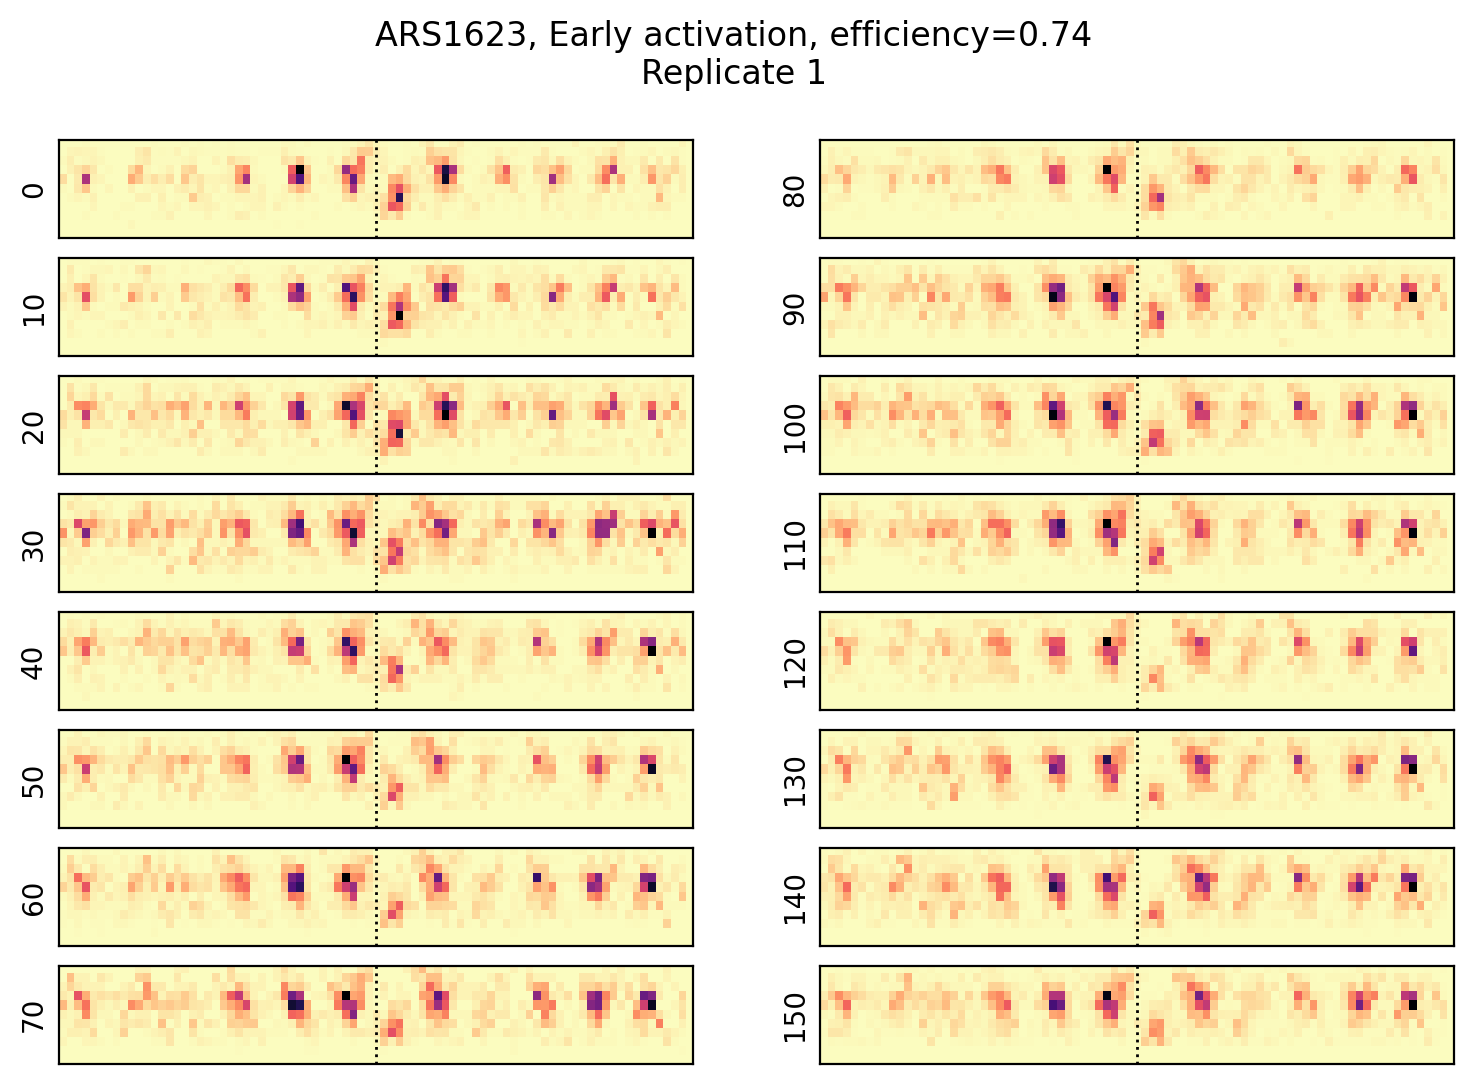

In [1689]:
fig = combined_model.plot_raw_origin_data(1)

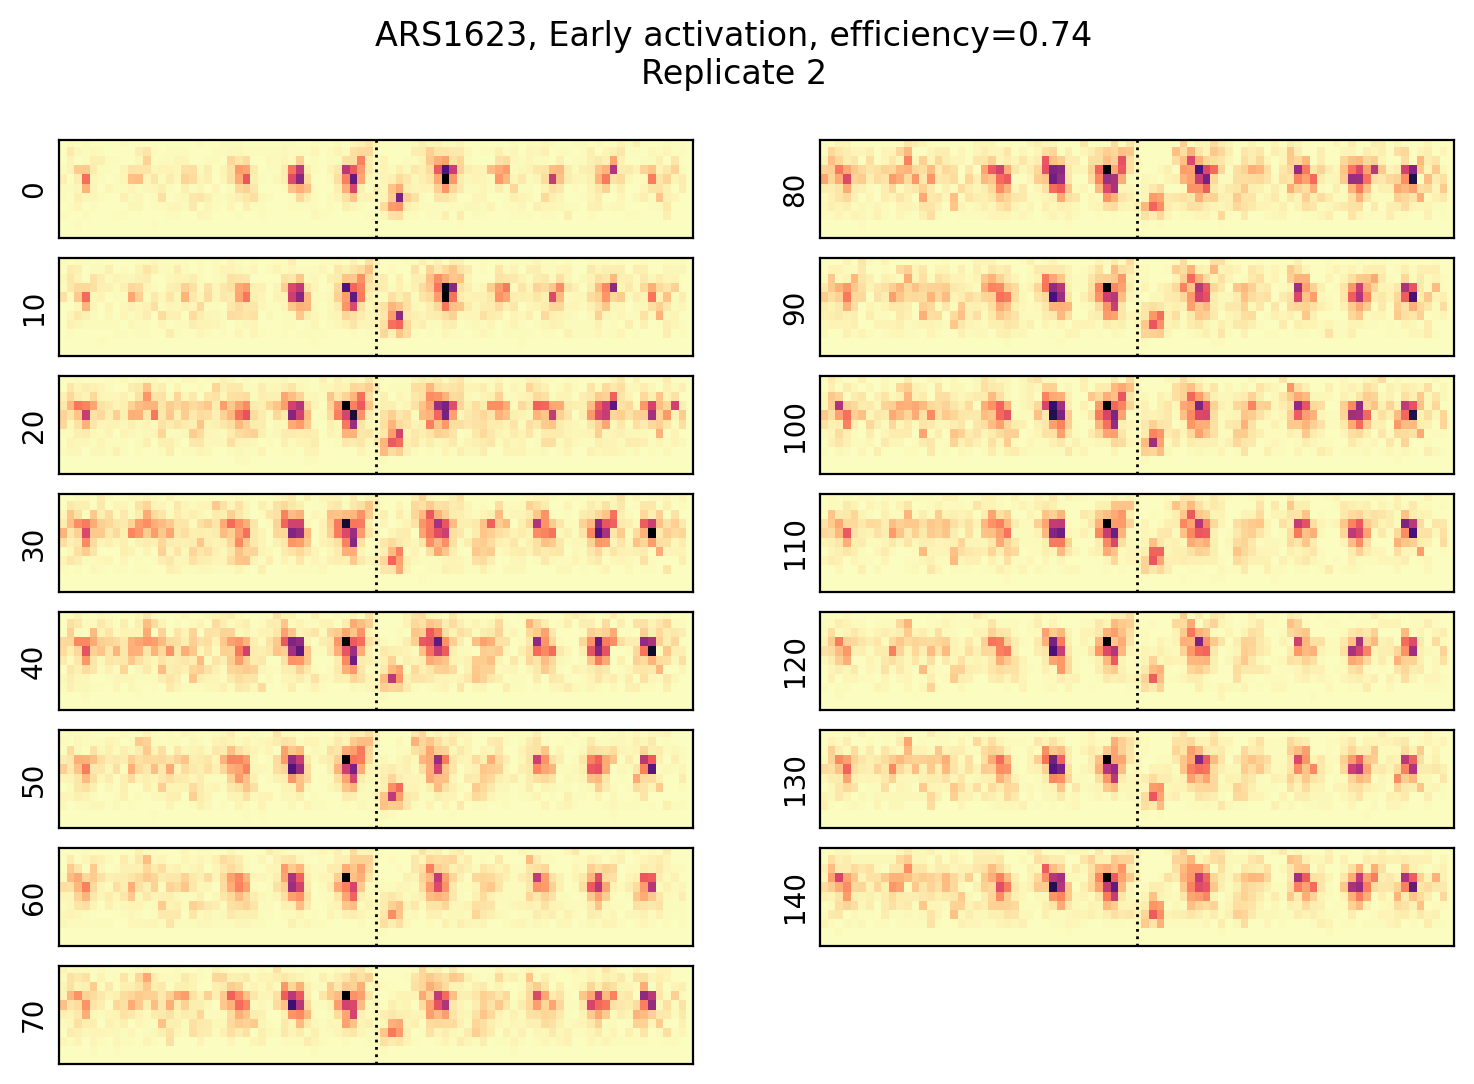

In [1690]:
fig = combined_model.plot_raw_origin_data(2)

In [1691]:
combined_model.find_origin_p1_and_m1_nucleosome_position()

Nucleosomal fragment length range:  (144, 192)
Origin fragment length range:  (24, 120)
The +1 span for tracking is: (633926, 634286)  length:  360
The -1 span for tracking is: (633566, 633926)  length:  360
The span for origin occupancy is: (633782, 634070)  length:  288
Nucleosomal fragment length range:  (144, 192)
Origin fragment length range:  (24, 120)
The +1 span for tracking is: (633926, 634286)  length:  360
The -1 span for tracking is: (633566, 633926)  length:  360
The span for origin occupancy is: (633782, 634070)  length:  288


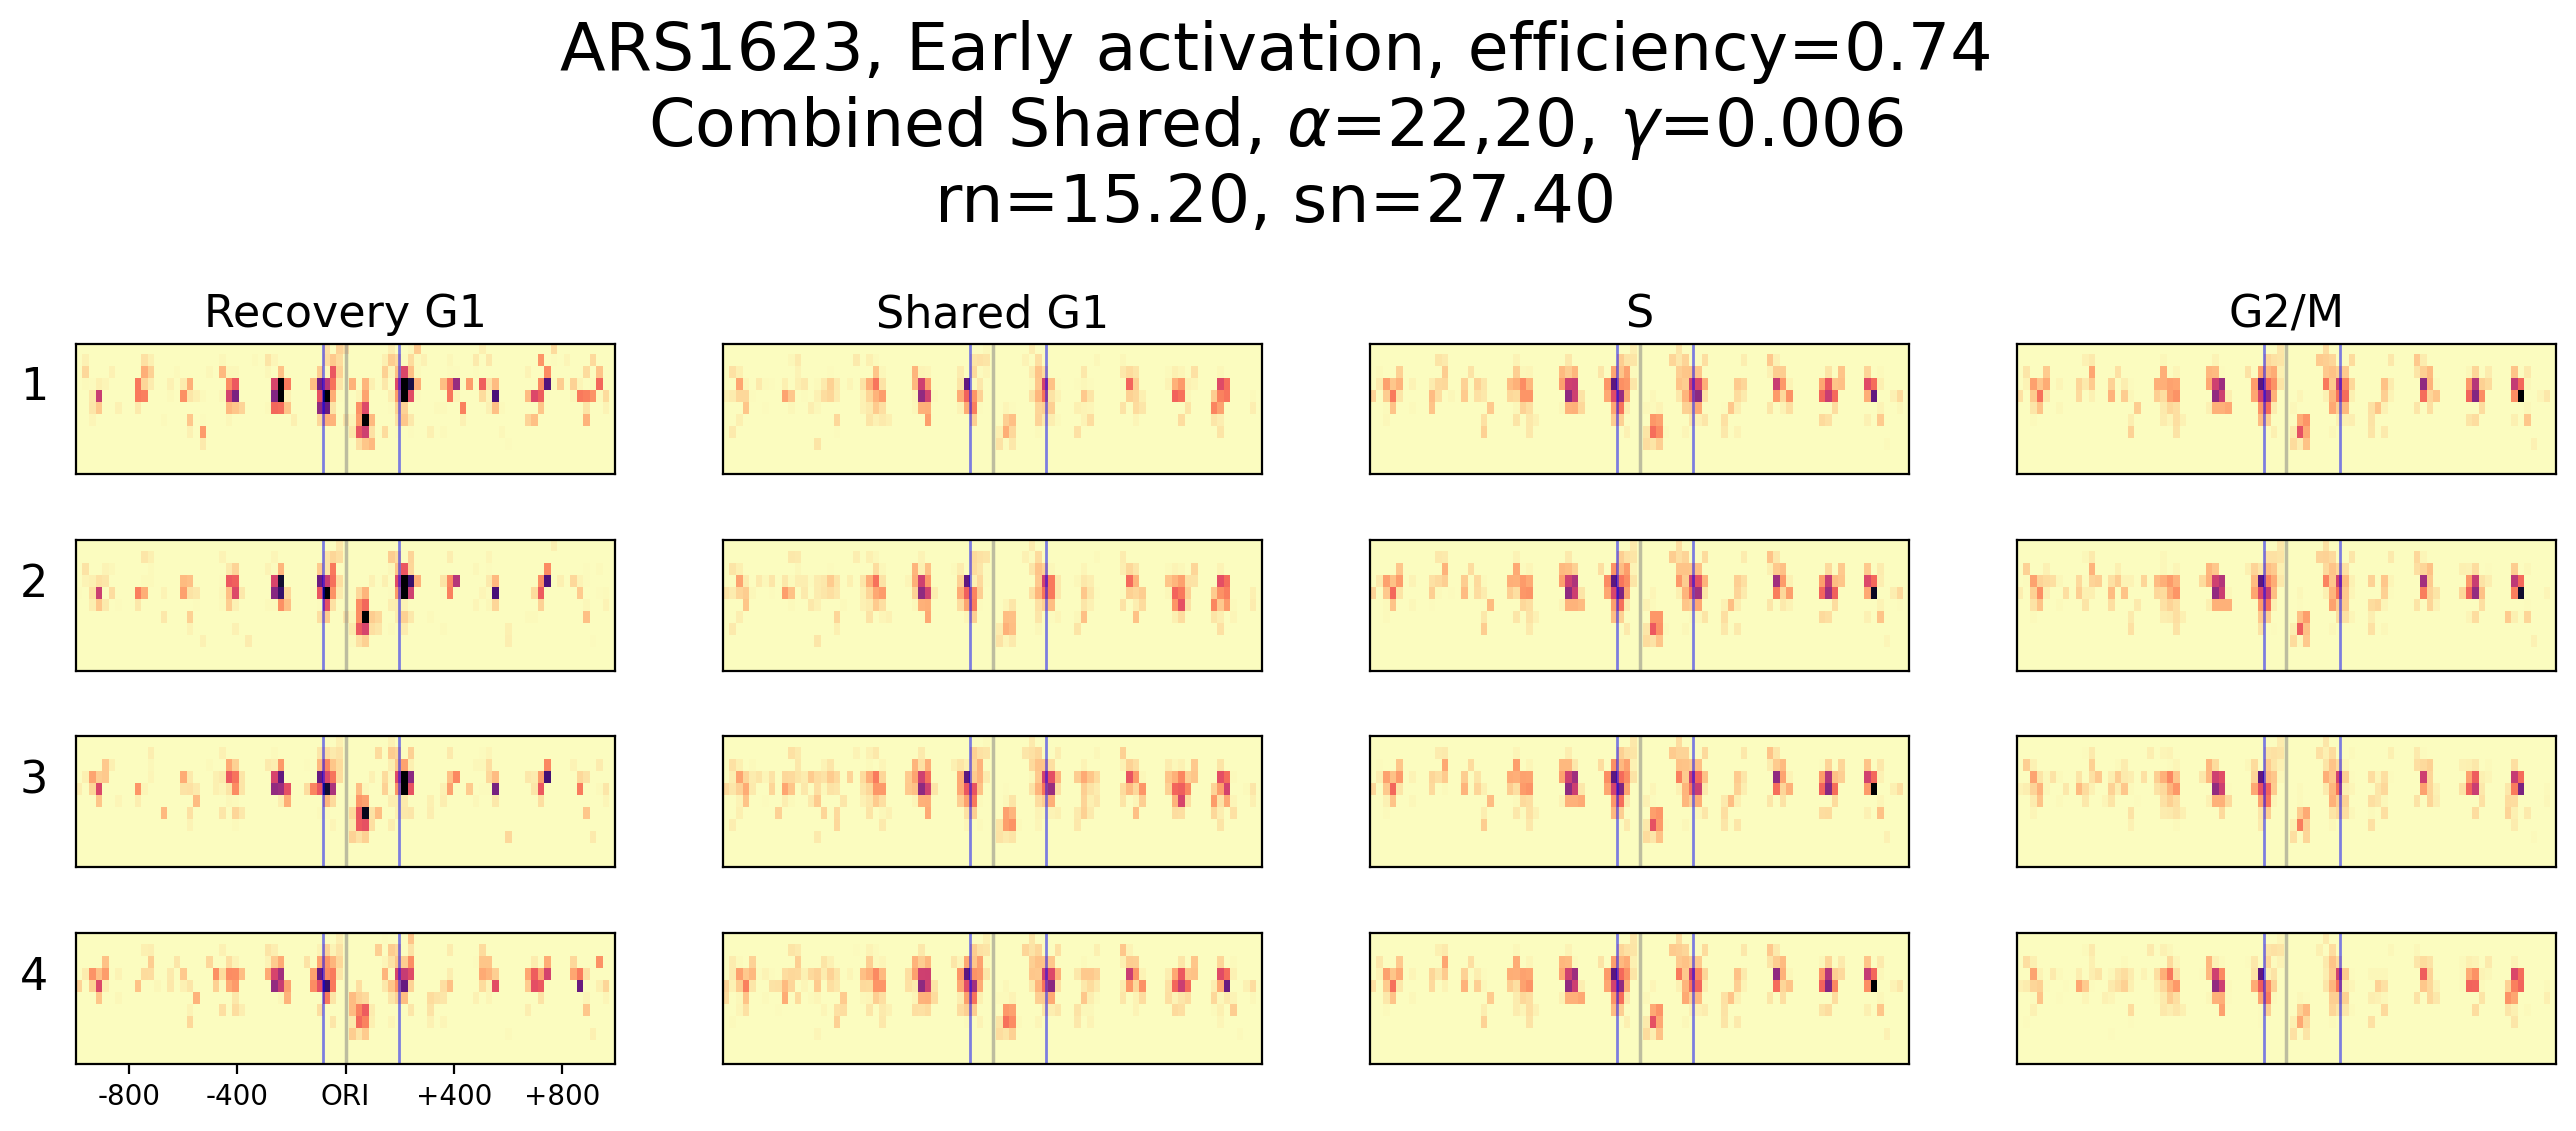

In [1692]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=75)

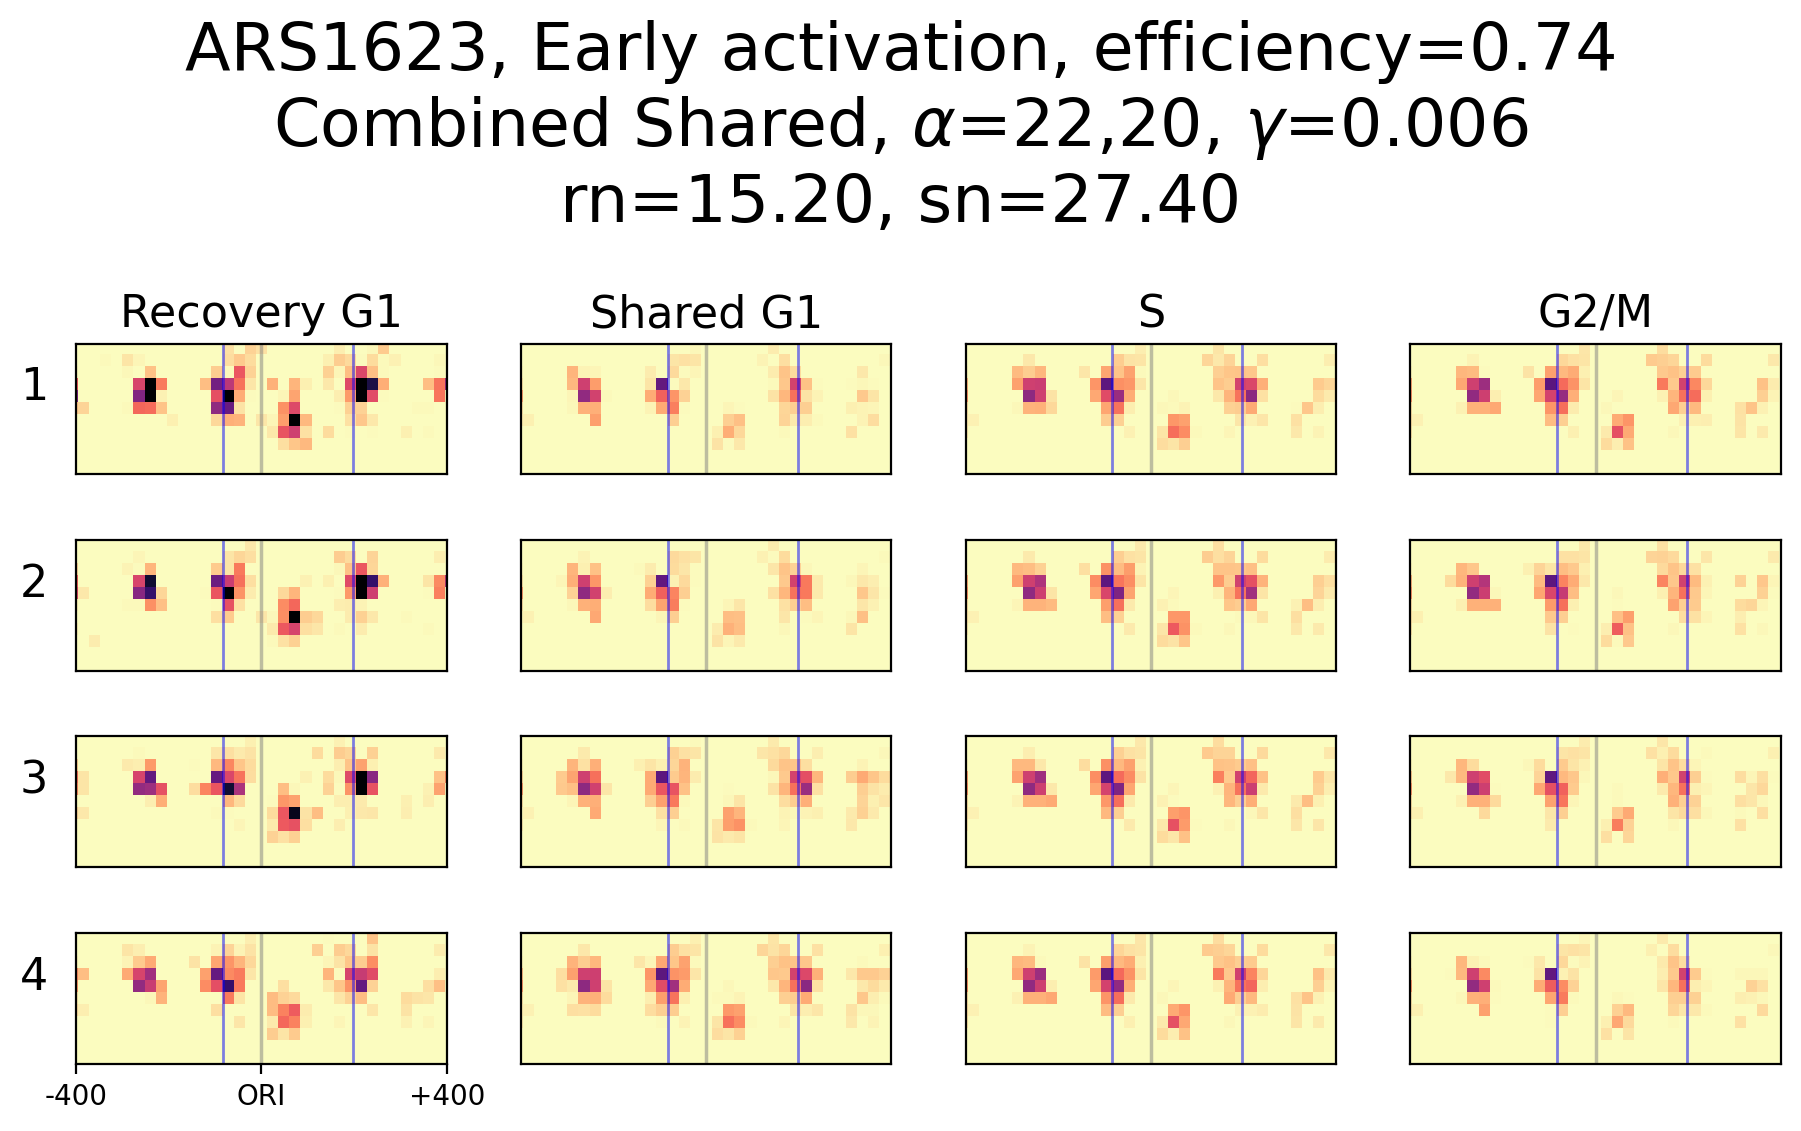

In [1693]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(zoom=800, vmax=75,
                                                                   num_rows=4)

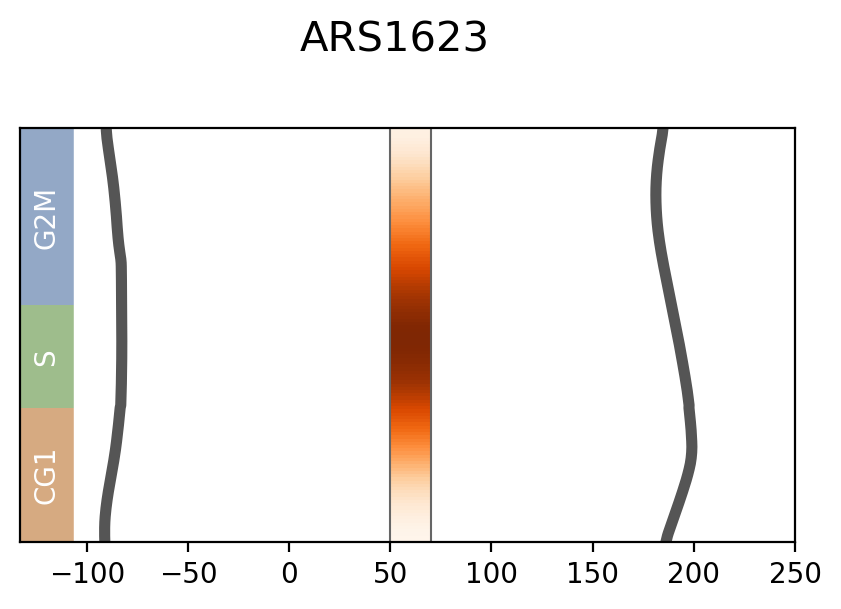

In [1697]:
fig = combined_model.chrom1_model.plot_nucleosome_shift()

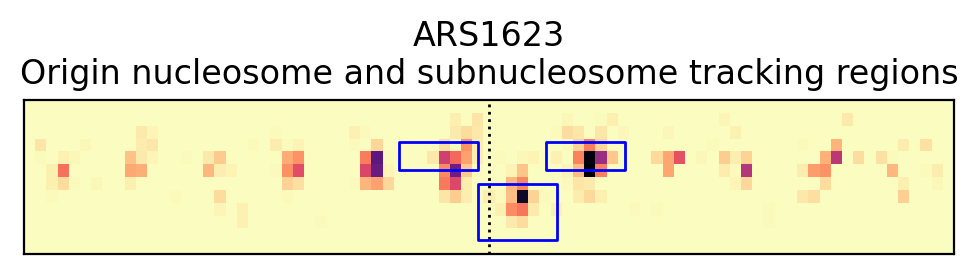

In [1695]:
fig = combined_model.chrom1_model.plot_origin_trackers()